# Steel Industry: カテゴリ変数を使ったUsage_kWhのOLS回帰

Day_of_week・Load_Type・時間帯(NSM)をそれぞれ探索してダミー変数化し、段階的にモデルへ追加していく。

In [5]:
import pandas as pd

df=pd.read_csv('..\data\Steel_industry_data.csv')
print(df.describe())
df.dtypes


          Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
count  35040.000000                          35040.000000   
mean      27.386892                             13.035384   
std       33.444380                             16.306000   
min        0.000000                              0.000000   
25%        3.200000                              2.300000   
50%        4.570000                              5.000000   
75%       51.237500                             22.640000   
max      157.180000                             96.910000   

       Leading_Current_Reactive_Power_kVarh     CO2(tCO2)  \
count                          35040.000000  35040.000000   
mean                               3.870949      0.011524   
std                                7.424463      0.016151   
min                                0.000000      0.000000   
25%                                0.000000      0.000000   
50%                                0.000000      0.000000   
75%                    

<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\owner\AppData\Local\Temp\ipykernel_12128\2829737834.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df=pd.read_csv('..\data\Steel_industry_data.csv')


date                                        str
Usage_kWh                               float64
Lagging_Current_Reactive.Power_kVarh    float64
Leading_Current_Reactive_Power_kVarh    float64
CO2(tCO2)                               float64
Lagging_Current_Power_Factor            float64
Leading_Current_Power_Factor            float64
NSM                                       int64
WeekStatus                                  str
Day_of_week                                 str
Load_Type                                   str
dtype: object

## 全体像の把握

各列を並べて時系列プロットし、ざっくりとした挙動を確認する。

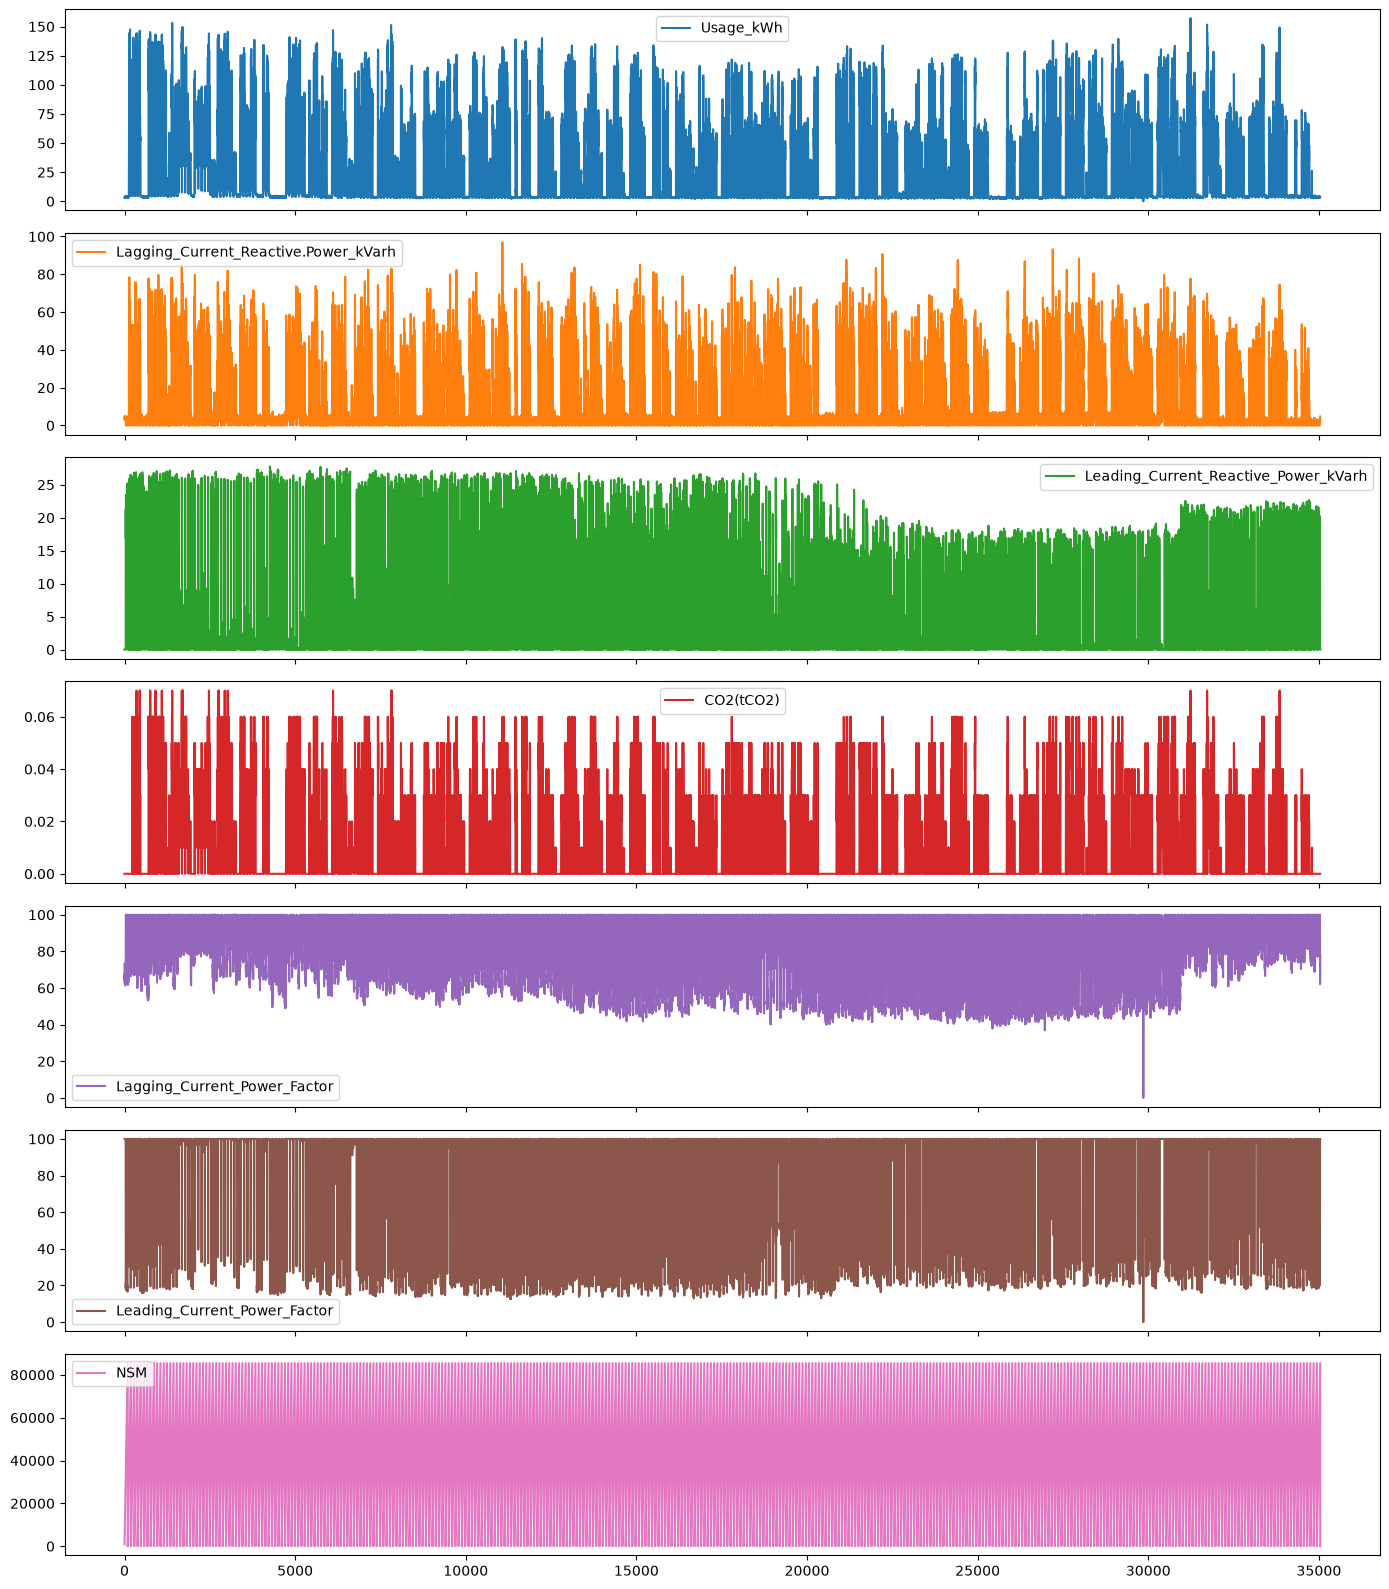

In [6]:
import matplotlib.pyplot as plt

df.plot(subplots=True, figsize=(14, 16))
plt.tight_layout()
plt.show()

## Day_of_week: 探索 → ダミー化 → OLS

曜日・週末平日別の平均を確認し、ダミー変数化してOLSに投入する。

In [7]:
print(df.groupby('WeekStatus')['Usage_kWh'].mean())
print(df.groupby('Day_of_week')['Usage_kWh'].mean())

WeekStatus
Weekday    33.624727
Weekend    11.732327
Name: Usage_kWh, dtype: float64
Day_of_week
Friday       33.195014
Monday       33.143935
Saturday     15.919020
Sunday        7.545633
Thursday     35.112083
Tuesday      34.427614
Wednesday    32.254235
Name: Usage_kWh, dtype: float64


In [8]:
day_dummies=pd.get_dummies(df['Day_of_week'],drop_first=True,dtype=int)
day_dummies

,Monday,Saturday,Sunday,Thursday,Tuesday,Wednesday
0,1,0,0,0,0,0
1,1,0,0,0,0,0
2,1,0,0,0,0,0
3,1,0,0,0,0,0
4,1,0,0,0,0,0
...,...,...,...,...,...,...
35035,1,0,0,0,0,0
35036,1,0,0,0,0,0
35037,1,0,0,0,0,0
35038,1,0,0,0,0,0


In [9]:
import statsmodels.api as sm

y=df['Usage_kWh']
X=sm.add_constant(day_dummies)
model=sm.OLS(y,X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Usage_kWh   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     594.6
Date:                Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:15:34   Log-Likelihood:            -1.7101e+05
No. Observations:               35040   AIC:                         3.420e+05
Df Residuals:                   35033   BIC:                         3.421e+05
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.1950      0.451     73.605      0.0

## NSM(時間帯)の探索

散布図とNSMごとの平均で日内パターンを確認し、山と谷の位置を特定する。

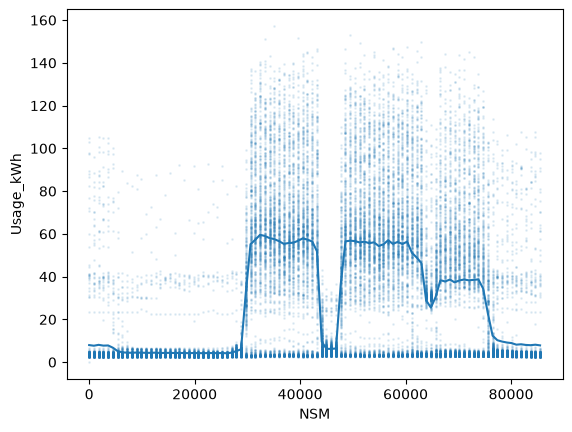

<Axes: xlabel='NSM'>

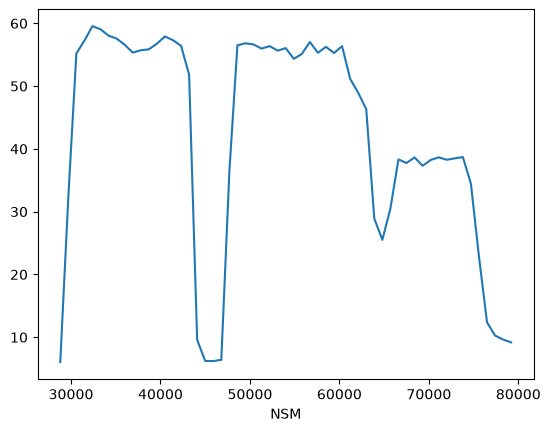

In [10]:


plt.scatter(df['NSM'],df['Usage_kWh'],alpha=0.1,s=1)
plt.xlabel('NSM')
plt.ylabel('Usage_kWh')

df.groupby('NSM')['Usage_kWh'].mean().plot()

plt.show()

nsm_mean = df.groupby('NSM')['Usage_kWh'].mean()

# 高い帯(28000〜80000)の中だけで最小値の位置を探す
nsm_mean[(nsm_mean.index > 28000) & (nsm_mean.index < 80000)].idxmin()

nsm_mean.loc[28000:80000].plot()

## Load_Type: ダミー化 → Day_of_week + Load_Type モデル

Load_Type(出力強度3段階)をダミー化し、既存のDay_of_weekモデルに追加する。

In [11]:
load_dummies=pd.get_dummies(df['Load_Type'],drop_first=True,dtype=int)
load_dummies

,Maximum_Load,Medium_Load
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
35035,0,0
35036,0,0
35037,0,0
35038,0,0


In [12]:
dummies=pd.concat([day_dummies,load_dummies],axis=1)

y=df['Usage_kWh']
X2=sm.add_constant(dummies)

model=sm.OLS(y,X2).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Usage_kWh   R-squared:                       0.411
Model:                            OLS   Adj. R-squared:                  0.411
Method:                 Least Squares   F-statistic:                     3056.
Date:                Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:15:34   Log-Likelihood:            -1.6343e+05
No. Observations:               35040   AIC:                         3.269e+05
Df Residuals:                   35031   BIC:                         3.270e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           12.9246      0.397     32.583   

## Time_Bin(山1/山2/山3): ダミー化 → 全変数を組み合わせたモデル

NSMの日内パターンから山1・山2・山3を切り出してダミー化し、Day_of_week + Load_Type に追加する。

In [18]:
import numpy as np

conditions = [
    df['NSM'].between(33000, 42000),   # 山1
    df['NSM'].between(48000, 61000),   # 山2
    df['NSM'].between(67000, 74000),   # 山3
]
choices = ['Peak1', 'Peak2', 'Peak3']

df['Time_Bin'] = np.select(conditions, choices, default='Base')
time_dummies = pd.get_dummies(df['Time_Bin'], drop_first=True, dtype=int)

df['Time_Bin'].value_counts()


Time_Bin
Base     23360
Peak2     5110
Peak1     3650
Peak3     2920
Name: count, dtype: int64

In [14]:
dummies3 = pd.concat([day_dummies, load_dummies, time_dummies], axis=1)

y = df['Usage_kWh']
X3 = sm.add_constant(dummies3)

model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:              Usage_kWh   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.484
Method:                 Least Squares   F-statistic:                     2989.
Date:                Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                        14:15:34   Log-Likelihood:            -1.6111e+05
No. Observations:               35040   AIC:                         3.222e+05
Df Residuals:                   35028   BIC:                         3.223e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           11.7009      0.372     31.480   